<a href="https://colab.research.google.com/github/miku390219/ml-practice/blob/main/2_PytorchAutomaticDifferentiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backward for scalar variables(変数)

requires_grad=Trueでこのテンソルへの勾配計算が有効になる

In [3]:
import torch
x = torch.arange(4.0, requires_grad = True)

In [4]:
x

tensor([0., 1., 2., 3.], requires_grad=True)

  x.grad->xの勾配
  逆伝播するまで未定


In [5]:
print(x.grad)

None


torch.dot(tensor1, tensor2)->一次元のベクトル同士の内積を計算

grad_fn = <DotBackward0>は「逆伝播の計算方法を記憶している」という意味

In [6]:
y = torch.dot(x, x)
print(y)

tensor(14., grad_fn=<DotBackward0>)


<tensor>.backward()で逆伝播
->x.grad ->xの勾配

In [7]:
y.backward()
print(x.grad)

tensor([0., 2., 4., 6.])


xの勾配の確認

In [8]:
x.grad == 2 * x

tensor([True, True, True, True])

## Backward for non-scalar variables

b.backward()の引数は、bがベクトルであるときに必要。(bがスカラーのときは不要)

b.backward(torch.tensor([1.0, 1.0, 1.0]))->bの要素を均等に1倍にして合計したものを偏微分

In [10]:
a = torch.arange(3.0, requires_grad = True)
b = a*a
b.backward(torch.tensor([1.0, 1.0, 1.0]))
print(a.grad)

tensor([0., 2., 4.])


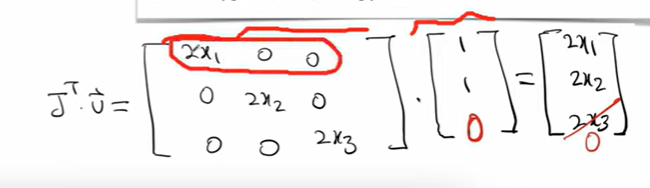

# Detaching computation

Detachしないタイプ

In [12]:
x = torch.arange(4.0, requires_grad=True)
y = x * x
u = y
z = u * x
z.sum().backward()
print(x.grad)

tensor([ 0.,  3., 12., 27.])


この場合、z = [x_1^3 x_2^3 ... ]

Detachするタイプ

In [13]:
x = torch.arange(4.0, requires_grad=True)
y = x * x
u = y.detach()
z = u * x
z.sum().backward()
print(x.grad)

tensor([0., 1., 4., 9.])


この場合、z = [u1x1 u2x2 ...]

u = yとするときに、yをxの変数ではなく、xに実際の数値(0, 1, 2, 3)を入れてからu=yとする